# <font color='blue'>Projeto para Análise de Vendas Para Loja de E-commerce com NumPy, Pandas e Matplotlib</font>

## 1. Definição do Problema de Negócio

**1.1. O Problema de Negócio**

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas de nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

- Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

- Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

- Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

- Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências.

**1.2. Objetivos do Projeto**

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
- Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

- Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

**1.3. Solução Proposta**

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (como Python com Pandas, NumPy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

**1.4. Resultados Esperados e Benefícios de Negócio**

Ao final deste projeto, esperamos alcançar os seguintes resultados:

- Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

- Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

- Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

- Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

## 2. Importação das Bibliotecas e Configuração Visual

In [1]:
# Importa o Pandas para manipulação e análise de tabelas de dados
import pandas as pd

# Importa o NumPy para cálculos numéricos e operações com matrizes
import numpy as np

# Importa o Matplotlib para criação e personalização de gráficos
import matplotlib.pyplot as plt

# Comando específico do Jupyter Notebook para exibir os gráficos diretamente na tela
%matplotlib inline

# Configuração visual padrão para tornar os gráficos mais limpos e legíveis
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 3. Carregamento e Preparação dos Dados

**Este bloco carrega os dados ou gera um conjunto representativo contendo datas, produtos, categorias, valores e regiões:**

In [2]:
# Importação dos módulos auxiliares do Python e das bibliotecas de dados
import random
from datetime import datetime, timedelta

# Define uma semente fixa para garantir que os dados gerados sejam sempre os mesmos
random.seed(42)
np.random.seed(42)

# Dicionário com o portfólio de produtos, suas respectivas categorias e preços unitários
catalogo = {
    'Notebook Dell': ('Informática', 4500.0),
    'Mouse Gamer': ('Informática', 150.0),
    'Teclado Mecânico': ('Informática', 350.0),
    'Smartphone Galaxy': ('Eletrônicos', 2800.0),
    'Fone Bluetooth': ('Eletrônicos', 220.0),
    'Smartwatch': ('Eletrônicos', 800.0),
    'Cadeira Ergonômica': ('Móveis', 1200.0),
    'Mesa de Escritório': ('Móveis', 750.0),
    'Monitor 27"': ('Informática', 1600.0),
    'Webcam HD': ('Informática', 290.0)
}

# Listas de apoio para seleção dos produtos e regiões
lista_produtos = list(catalogo.keys())
lista_estados = ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA']
pesos_estados = [0.35, 0.20, 0.15, 0.10, 0.08, 0.07, 0.05]

# Data de referência inicial para o ano de vendas
data_inicial = datetime(2025, 1, 1)
registros = []

# Laço para criar 1.200 transações de venda completas
for i in range(1200):
    # Gera um identificador único para cada pedido
    id_pedido = 1001 + i
    
    # Distribui as transações uniformemente ao longo dos 365 dias do ano
    data_venda = data_inicial + timedelta(days=int((i / 1200) * 364), hours=random.randint(8, 20))
    
    # Seleciona aleatoriamente um produto e obtém seus dados
    produto = random.choice(lista_produtos)
    categoria, preco_unitario = catalogo[produto]
    
    # Define a quantidade comprada (de 1 a 4 unidades)
    quantidade = random.randint(1, 4)
    
    # Sorteia o estado do cliente respeitando a distribuição de mercado
    estado = random.choices(lista_estados, weights=pesos_estados, k=1)[0]
    
    # Calcula a receita multiplicando a quantidade pelo preço unitário
    valor_total = quantidade * preco_unitario
    
    # Salva o registro da venda individual na lista
    registros.append({
        'ID_Pedido': id_pedido,
        'Data_Venda': data_venda,
        'Produto': produto,
        'Categoria': categoria,
        'Preco_Unitario': preco_unitario,
        'Quantidade': quantidade,
        'Estado': estado,
        'Valor_Total': valor_total
    })

# Converte a lista de registros estruturados em um DataFrame do Pandas
df = pd.DataFrame(registros)

# Garante o tipo datetime para operações temporais
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])

# Exibe o total de transações geradas e as primeiras 5 linhas da tabela
print(f"Base de dados simulada criada com sucesso! Total de registros: {len(df)}")
df.head()

Base de dados simulada criada com sucesso! Total de registros: 1200


,ID_Pedido,Data_Venda,Produto,Categoria,Preco_Unitario,Quantidade,Estado,Valor_Total
0,1001,2025-01-01 18:00:00,Mouse Gamer,Informática,150.0,1,RS,150.0
1,1002,2025-01-01 11:00:00,Smartphone Galaxy,Eletrônicos,2800.0,2,RS,5600.0
2,1003,2025-01-01 18:00:00,"Monitor 27""",Informática,1600.0,1,MG,1600.0
3,1004,2025-01-01 08:00:00,Notebook Dell,Informática,4500.0,1,SP,4500.0
4,1005,2025-01-02 16:00:00,Webcam HD,Informática,290.0,1,MG,290.0


## Pergunta 1 — O que vender? (Top & Bottom Produtos)

**Identifica quais produtos têm maior e menor volume de vendas para otimização de compras e controle de estoque:**

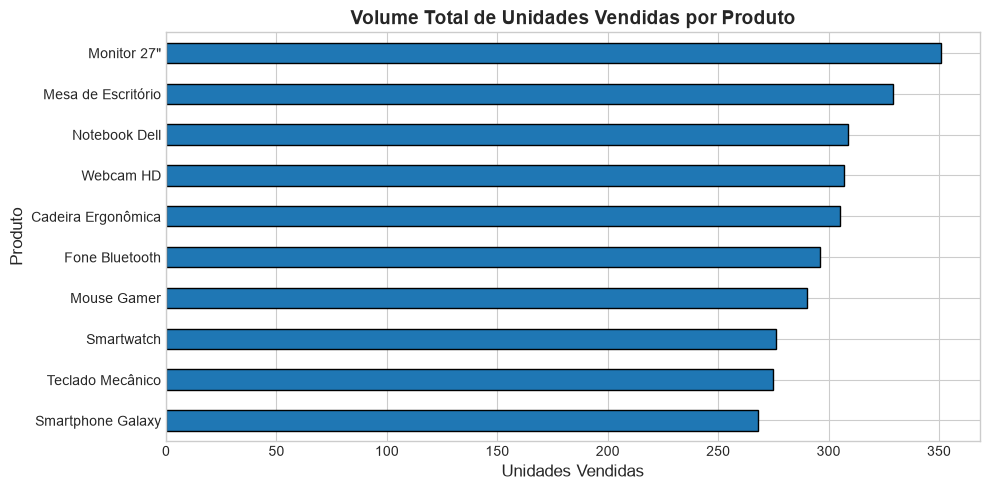

--- PRODUTOS MAIS VENDIDOS ---
Produto
Notebook Dell         309
Mesa de Escritório    329
Monitor 27"           351
Name: Quantidade, dtype: int64

--- PRODUTOS MENOS VENDIDOS ---
Produto
Smartphone Galaxy    268
Teclado Mecânico     275
Smartwatch           276
Name: Quantidade, dtype: int64


In [3]:
# Agrupa os dados por Produto e soma a quantidade total vendida de cada item
vendas_por_produto = df.groupby('Produto')['Quantidade'].sum().sort_values(ascending=True)

# Cria a figura para o gráfico
plt.figure(figsize=(10, 5))

# Plota um gráfico de barras horizontais
vendas_por_produto.plot(kind='barh', color='#1f77b4', edgecolor='black')

# Adiciona títulos e rótulos aos eixos
plt.title('Volume Total de Unidades Vendidas por Produto', fontsize=14, fontweight='bold')
plt.xlabel('Unidades Vendidas', fontsize=12)
plt.ylabel('Produto', fontsize=12)

# Exibe o gráfico na tela
plt.tight_layout()
plt.show()

# Exibe os dados numéricos consolidados
print("--- PRODUTOS MAIS VENDIDOS ---")
print(vendas_por_produto.tail(3))

print("\n--- PRODUTOS MENOS VENDIDOS ---")
print(vendas_por_produto.head(3))

## Pergunta 2 — Onde focar? (Faturamento por Categoria)

**Avalia quais categorias representam a maior fatia da receita total gerada pela loja:**

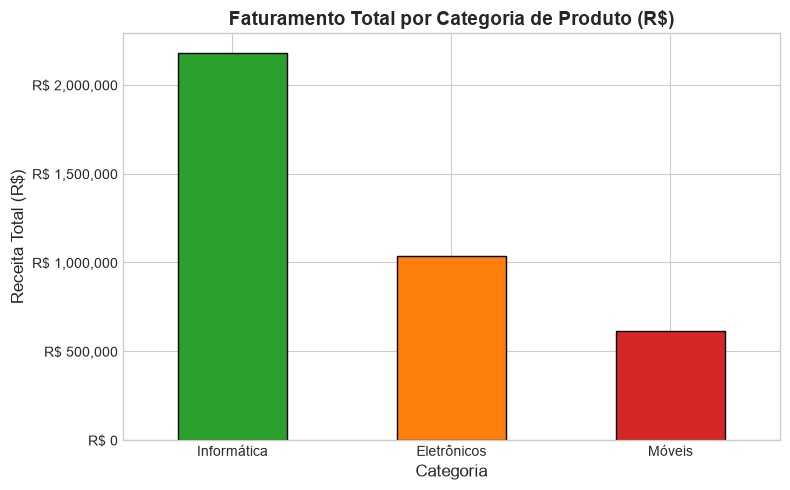

             Receita (R$)  Participação (%)
Categoria                                  
Informática     2180880.0             56.94
Eletrônicos     1036320.0             27.06
Móveis           612750.0             16.00


In [4]:
# Agrupa por categoria e calcula o faturamento total gerado
faturamento_por_categoria = df.groupby('Categoria')['Valor_Total'].sum().sort_values(ascending=False)

# Configura a exibição gráfica
plt.figure(figsize=(8, 5))

# Plota as barras verticais com a receita por categoria
faturamento_por_categoria.plot(kind='bar', color=['#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black')

plt.title('Faturamento Total por Categoria de Produto (R$)', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Receita Total (R$)', fontsize=12)
plt.xticks(rotation=0)

# Formata o eixo Y para facilitar a leitura monetária
plt.gca().yaxis.set_major_formatter('R$ {:,.0f}'.format)

plt.tight_layout()
plt.show()

# Tabela percentual de participação de cada categoria
percentual_receita = (faturamento_por_categoria / df['Valor_Total'].sum()) * 100
tabela_categoria = pd.DataFrame({
    'Receita (R$)': faturamento_por_categoria,
    'Participação (%)': percentual_receita
})
print(tabela_categoria.round(2))

## Pergunta 3 — Quando agir? (Análise Temporal e Sazonalidade)

**Mapeia o faturamento mês a mês para identificar tendências, sazonalidades e períodos de pico:**

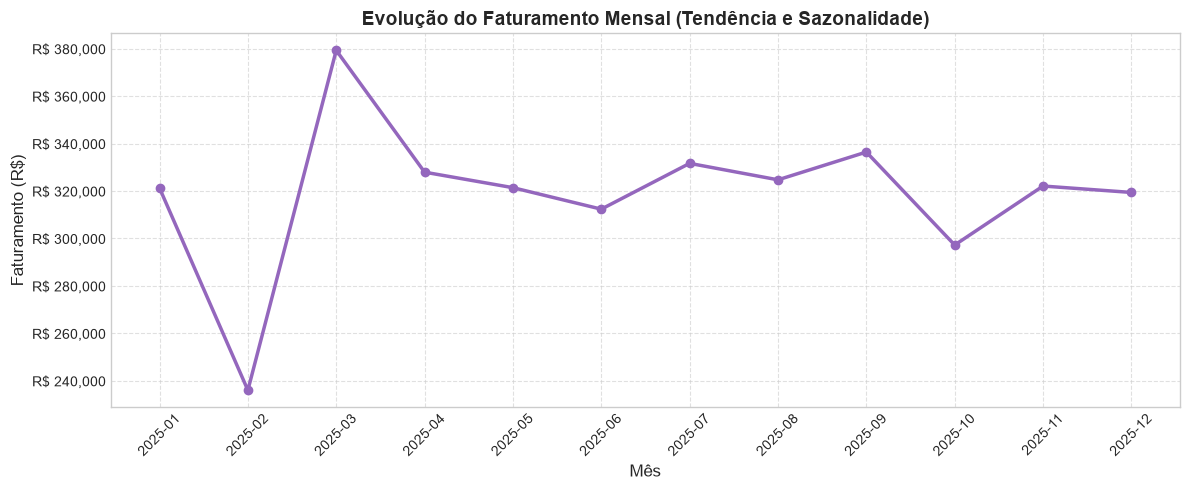

In [5]:
# Cria uma coluna com o período no formato Ano-Mês (ex: 2025-01)
df['Ano_Mes'] = df['Data_Venda'].dt.to_period('M')

# Agrupa por mês e soma o faturamento total
faturamento_mensal = df.groupby('Ano_Mes')['Valor_Total'].sum()

# Converte o índice de volta para string para plotagem linear contínua
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

plt.figure(figsize=(12, 5))

# Plota o gráfico de linha temporal com marcadores circulares nos meses
plt.plot(faturamento_mensal.index, faturamento_mensal.values, marker='o', color='#9467bd', linewidth=2.5)

plt.title('Evolução do Faturamento Mensal (Tendência e Sazonalidade)', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.gca().yaxis.set_major_formatter('R$ {:,.0f}'.format)

plt.tight_layout()
plt.show()

## Pergunta 4 — Para onde expandir? (Distribuição Regional)

**Analisa a concentração geográfica das vendas para direcionar estratégias de marketing e expansão logística:**

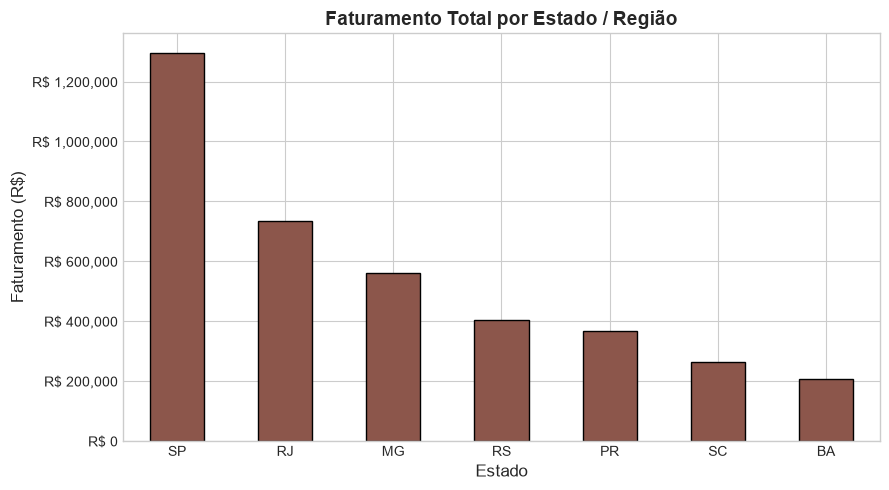

        Faturamento_Total  Total_Pedidos
Estado                                  
SP              1296370.0            415
RJ               733860.0            225
MG               561130.0            173
RS               403610.0            136
PR               366040.0            102
SC               262660.0             87
BA               206280.0             62


In [6]:
# Agrupa por estado e calcula a receita total e o volume de pedidos
vendas_por_estado = df.groupby('Estado').agg(
    Faturamento_Total=('Valor_Total', 'sum'),
    Total_Pedidos=('ID_Pedido', 'count')
).sort_values(by='Faturamento_Total', ascending=False)

plt.figure(figsize=(9, 5))

# Plota a receita total por estado
vendas_por_estado['Faturamento_Total'].plot(kind='bar', color='#8c564b', edgecolor='black')

plt.title('Faturamento Total por Estado / Região', fontsize=14, fontweight='bold')
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter('R$ {:,.0f}'.format)

plt.tight_layout()
plt.show()

# Exibe a tabela de desempenho regional
print(vendas_por_estado)

## Guia de Aplicação dos Insights de Negócio

* **Gestão de Estoque:** Priorize o reabastecimento dos 3 itens com maior saída de unidades e realize liquidações promocionais dos itens na base do ranking para liberar capital de giro.


* **Alocação de Marketing:** Concentre o orçamento de anúncios nas categorias de maior ticket e participação na receita.


* **Planejamento Sazonal:** Use a curva temporal mensal para programar campanhas em meses historicamente fracos e reforçar a logística nos meses de pico.


* **Expansão Logística:** Foque contratos de frete rápido e centros de distribuição nos estados que concentram a maior parte do faturamento.